# Physics-Based SOH Estimation From Charge Events

This notebook does two things:
1. inspects the raw assets under `data/` so the available signals are explicit;
2. compares a physics-based SOH estimate to the observed SOH points for the electric aircraft battery.

The chosen estimator is charge-event coulomb counting:

- `Q_delivered = \int |I| dt / 3600`
- `C_hat = Q_delivered / (\Delta SOC / 100)`
- `SOH_abs = 100 * C_hat / C_rated`
- `SOH_rel = 100 * C_hat / C_ref`

`SOH_abs` is absolute capacity relative to the rated pack capacity from `ml_workspace/battery_specs.yaml`.
`SOH_rel` is normalized to the early-life reference capacity estimated from the first few charge events for each battery.

For runtime and reproducibility, the notebook uses the repo's validated charge-event summary in `ml_workspace/battery_inference/output/plane_<id>/charge_event_capacity_summary.csv`, which is already derived from the raw parquet telemetry in `data/event_timeseries_corrected.parquet`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'data').exists() and (path / 'ml_workspace').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml_workspace.soh_estimation.physics_based_soh import inspect_data_directory, load_charge_physics_dataset, score_models

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')

PLANE_ID = '166'
REFERENCE_EVENTS = 10

## 1. What is available under `data/`?

The raw parquet files should tell us whether a physics-based estimator is feasible. For charge-event capacity estimation we need, at minimum:

- event segmentation and event type labels;
- a per-row time base;
- battery current during charging;
- battery SOC during charging;
- observed BMS SOH points to compare against.

In [2]:
file_summary, manifest_summary, telemetry_summary = inspect_data_directory()

print('Raw data files')
display(file_summary)

print('Event counts by plane and corrected event type')
display(manifest_summary)

print('Telemetry channels used by the physics estimator')
display(telemetry_summary)

Raw data files


,file,size_mb,rows,columns
0,event_manifest.parquet,0.17,649,34
1,event_manifest_corrected.parquet,0.19,649,51
2,event_timeseries.parquet,2253.59,32285002,416
3,event_timeseries_corrected.parquet,1970.86,32285002,426


Event counts by plane and corrected event type


,plane_id,event_type_main_corrected,events
0,166,charging,324
1,166,flight,200
2,166,ground_test,59
3,166,unknown,1
4,192,charging,39
5,192,flight,26


Telemetry channels used by the physics estimator


,selected_column,available,why_it_matters
0,time_ms,True,Per-row time base for coulomb counting.
1,pack_current,True,Pack-level charge/discharge current.
2,pack_soc,True,Pack SOC trajectory.
3,pack_temp_avg,True,Pack thermal exposure during events.
4,bat 1 current,True,Battery 1 current for per-pack capacity estima...
5,bat 1 soc,True,Battery 1 SOC window selection.
6,bat 1 soh,True,Battery 1 observed BMS SOH points.
7,bat 1 avg cell temp,True,Battery 1 thermal exposure.
8,bat 2 current,True,Battery 2 current for per-pack capacity estima...
9,bat 2 soc,True,Battery 2 SOC window selection.


## 2. Load the physics-based charge summary and observed SOH points

The merged table below contains one row per charge event and battery.

Key columns:
- `capacity_est_ah`: coulomb-counted capacity estimate for that charge event.
- `physics_soh_absolute_pct`: `capacity_est_ah / rated_capacity_ah`.
- `physics_soh_relative_pct`: `capacity_est_ah / reference_capacity_ah`, where the reference is the median of the first `REFERENCE_EVENTS` charge events for that battery.
- `observed_soh_pct`: observed SOH point carried from the event observation table.

In [3]:
charge_df = load_charge_physics_dataset(plane_id=PLANE_ID, reference_events=REFERENCE_EVENTS)
charge_df.head(12)

,flight_id,battery_id,event_datetime,soc_start,soc_end,soc_span,soc_window_used,delivered_ah,capacity_est_ah,cap_est_raw_median,v_max,v_p99,rows_used,monotonic_soc_frac,observed_soh_pct,plane_id,rated_capacity_ah,physics_soh_absolute_pct,reference_capacity_ah,physics_soh_relative_pct,days_from_start
0,4577,1,2023-05-16 13:00:00,29.0,100.0,71.0,40-90,14.404364,28.808729,9519.0,403.9,403.8,18774,1.0,97.0,166,29.4,97.988874,28.4328,101.322165,0.000000
1,4579,1,2023-05-16 15:00:00,29.0,100.0,71.0,40-90,14.219975,28.439950,9503.0,404.5,403.8,20922,1.0,96.0,166,29.4,96.734525,28.4328,100.025147,0.083333
2,4581,1,2023-05-16 20:00:00,27.0,100.0,73.0,40-90,14.118301,28.236603,9528.0,403.9,403.8,19540,1.0,97.0,166,29.4,96.042866,28.4328,99.309960,0.291667
3,4586,1,2023-05-17 14:00:00,29.0,95.0,66.0,40-90,14.131061,28.262121,9500.0,403.0,402.4,19089,1.0,96.0,166,29.4,96.129664,28.4328,99.399711,1.041667
4,4589,1,2023-05-17 16:00:00,28.0,92.0,64.0,40-90,14.043432,28.086864,9447.0,403.8,403.3,17092,1.0,95.0,166,29.4,95.533551,28.4328,98.783320,1.125000
5,4591,1,2023-05-17 18:00:00,29.0,94.0,65.0,40-90,14.212825,28.425650,9498.0,403.8,403.3,15508,1.0,96.0,166,29.4,96.685885,28.4328,99.974853,1.208333
6,4593,1,2023-05-17 20:00:00,29.0,97.0,68.0,40-90,14.511265,29.022531,9536.0,403.9,403.8,17354,1.0,98.0,166,29.4,98.716090,28.4328,102.074120,1.291667
7,4574,1,2023-05-19 12:04:00,29.0,96.0,67.0,40-90,14.382662,28.765323,9520.0,402.6,402.2,16406,1.0,97.0,166,29.4,97.841235,28.4328,101.169505,2.961111
8,4588,1,2023-05-19 16:00:00,28.0,92.0,64.0,40-90,14.043432,28.086864,9447.0,403.8,403.3,17092,1.0,95.0,166,29.4,95.533551,28.4328,98.783320,3.125000
9,4621,1,2023-06-03 11:00:00,33.0,100.0,67.0,40-90,14.290366,28.580731,9513.0,403.8,403.8,17123,1.0,97.0,166,29.4,97.213372,28.4328,100.520283,17.916667


In [4]:
charge_df.groupby('battery_id')[['capacity_est_ah', 'physics_soh_absolute_pct', 'physics_soh_relative_pct', 'observed_soh_pct']].describe().round(2)

capacity_est_ah                                                 physics_soh_absolute_pct                                                  \
                     count   mean   std    min    25%    50%    75%    max                    count   mean   std    min    25%    50%    75%    max   
battery_id                                                                                                                                            
1                    134.0  26.07  1.32  23.18  24.87  25.92  27.10  29.02                    134.0  88.69  4.50  78.84  84.61  88.16  92.17  98.72   
2                    127.0  26.42  1.26  23.80  25.35  26.31  27.41  29.05                    127.0  89.87  4.28  80.95  86.22  89.49  93.24  98.80   

           physics_soh_relative_pct                                                  observed_soh_pct                                              
                              count   mean   std    min    25%    50%    75%     max            count   mean    std   min   25%   50%   75%   max  
battery_id                                                                                                                                         
1                             134.0  91.71  4.65  81.53  87.48  91.16  95.30  102.07            134.0  80.28  10.74  57.0  71.0  78.5  90.0  98.0  
2                             127.0  92.54  4.41  83.36  88.79  92.15  96.01  101.73            127.0  83.18  10.10  61.0  74.0  82.0  93.0  98.0

## 3. Score the physics estimate against observed SOH points

This is a descriptive comparison, not a train/test machine-learning benchmark. The main question is whether the charge-derived capacity estimate tracks the observed SOH trajectory closely enough to be useful.

In [5]:
metrics = score_models(charge_df)
metrics.round(3)

,model,scope,n,mae,rmse,r2
0,physics_soh_absolute_pct,battery_1,134,8.677,10.665,0.007
1,physics_soh_absolute_pct,battery_2,127,7.088,9.066,0.188
2,physics_soh_absolute_pct,overall,261,7.904,9.919,0.106
3,physics_soh_relative_pct,battery_1,134,11.431,13.110,-0.501
4,physics_soh_relative_pct,battery_2,127,9.357,11.122,-0.223
5,physics_soh_relative_pct,overall,261,10.422,12.183,-0.348


## 4. Time-series comparison by battery

`physics_soh_absolute_pct` is the most direct physical interpretation because it uses rated capacity as the baseline.
`physics_soh_relative_pct` is useful when the observed SOH stream appears internally normalized by the aircraft/BMS rather than by the pack's nominal new capacity.

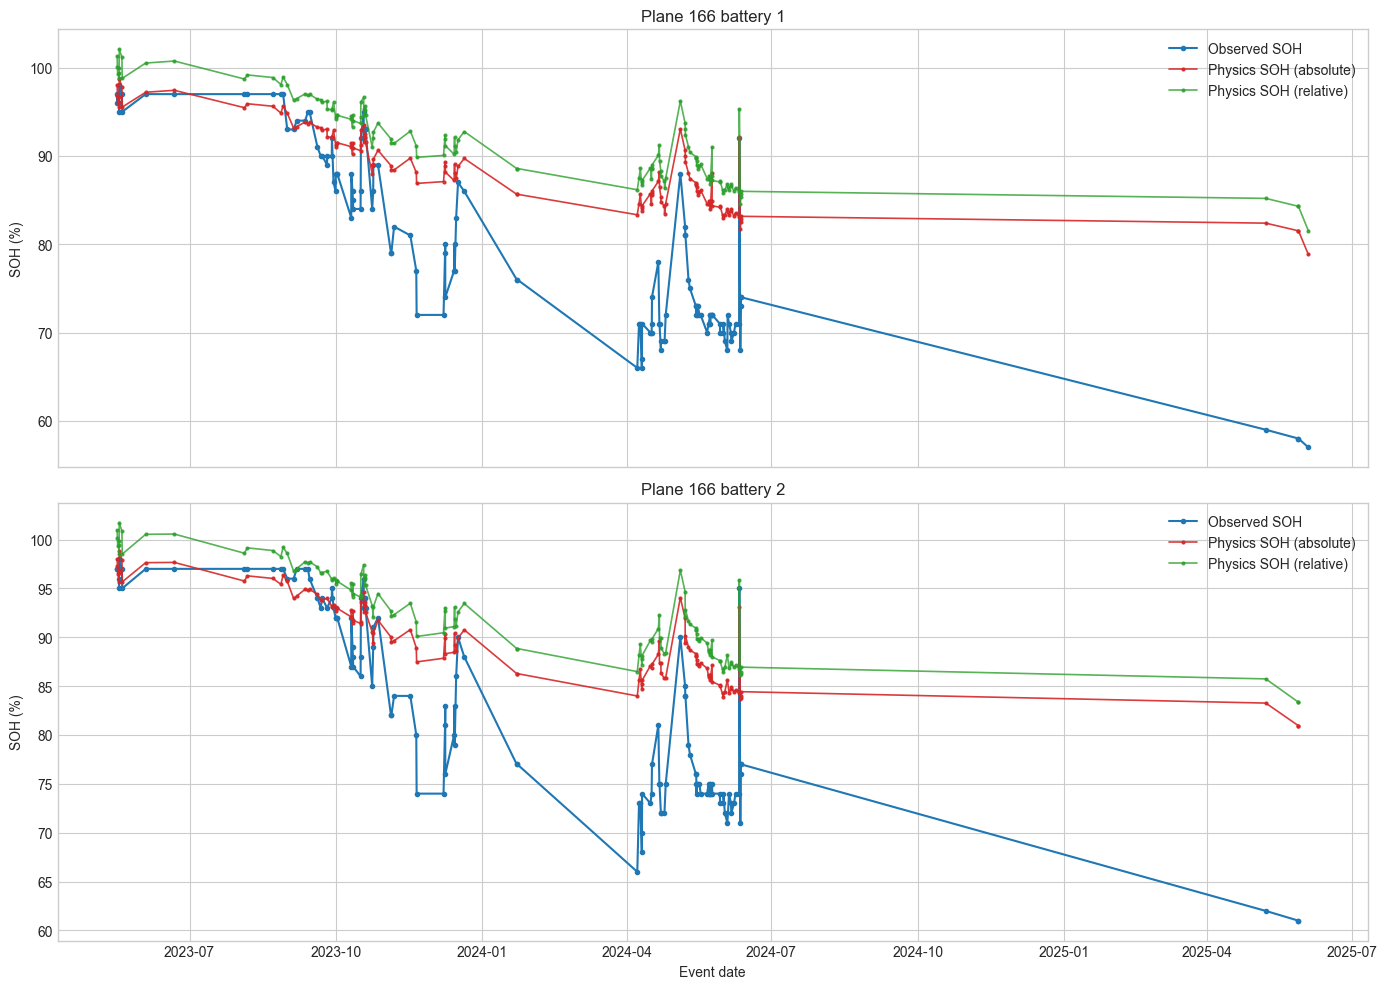

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
for ax, (battery_id, battery_frame) in zip(axes, charge_df.groupby('battery_id')):
    battery_frame = battery_frame.sort_values('event_datetime')
    ax.plot(battery_frame['event_datetime'], battery_frame['observed_soh_pct'], marker='o', markersize=3, linewidth=1.5, label='Observed SOH', color='#1f77b4')
    ax.plot(battery_frame['event_datetime'], battery_frame['physics_soh_absolute_pct'], marker='o', markersize=2, linewidth=1.2, label='Physics SOH (absolute)', color='#d62728', alpha=0.9)
    ax.plot(battery_frame['event_datetime'], battery_frame['physics_soh_relative_pct'], marker='o', markersize=2, linewidth=1.2, label='Physics SOH (relative)', color='#2ca02c', alpha=0.8)
    ax.set_title(f'Plane {PLANE_ID} battery {battery_id}')
    ax.set_ylabel('SOH (%)')
    ax.legend(loc='best')
axes[-1].set_xlabel('Event date')
plt.tight_layout()
plt.show()

## 5. Observed vs. physics scatter

Points on the dashed line would indicate perfect agreement.

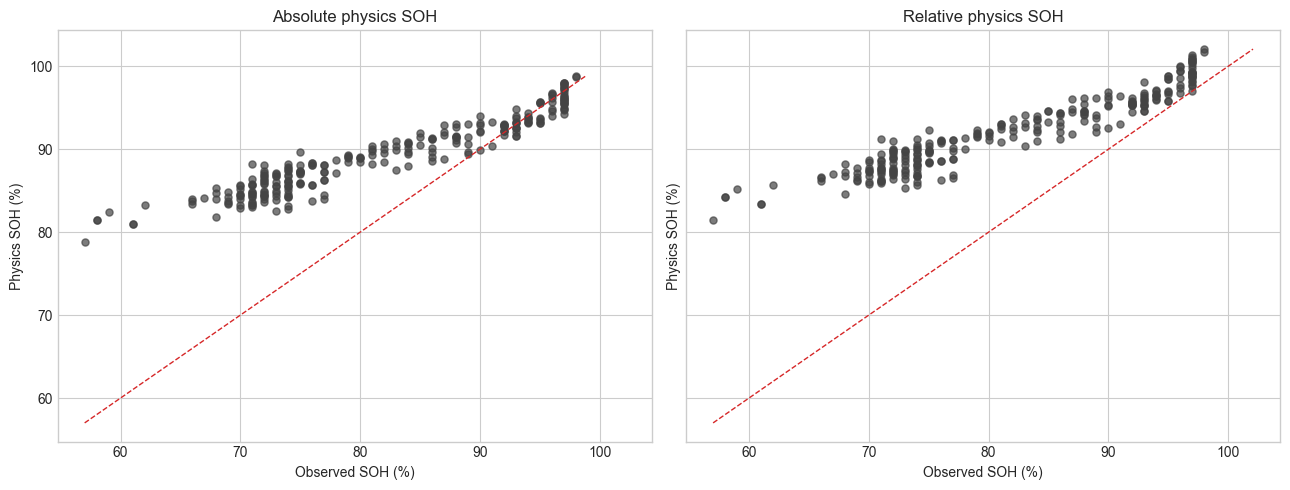

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
plot_specs = [
    ('physics_soh_absolute_pct', 'Absolute physics SOH'),
    ('physics_soh_relative_pct', 'Relative physics SOH'),
]
for ax, (column, title) in zip(axes, plot_specs):
    ax.scatter(charge_df['observed_soh_pct'], charge_df[column], alpha=0.7, s=26, color='#444444')
    bounds = [
        min(charge_df['observed_soh_pct'].min(), charge_df[column].min()),
        max(charge_df['observed_soh_pct'].max(), charge_df[column].max()),
    ]
    ax.plot(bounds, bounds, linestyle='--', color='#d62728', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('Observed SOH (%)')
    ax.set_ylabel('Physics SOH (%)')
plt.tight_layout()
plt.show()

## 6. Capacity trajectory in amp-hours

This plot is useful because it removes the SOH normalization issue entirely and shows the underlying capacity estimate directly.

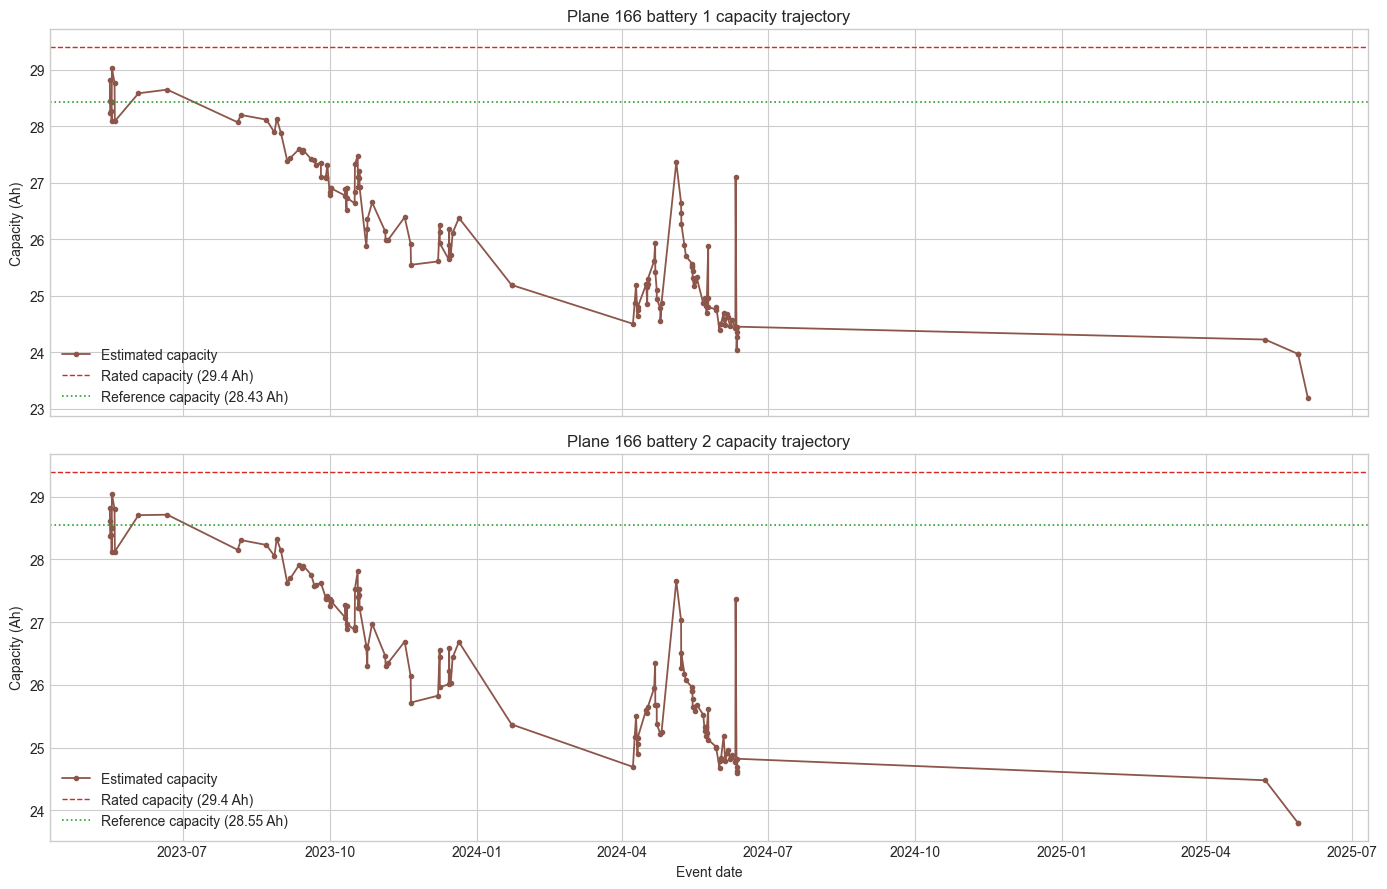

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for ax, (battery_id, battery_frame) in zip(axes, charge_df.groupby('battery_id')):
    battery_frame = battery_frame.sort_values('event_datetime')
    rated_capacity = battery_frame['rated_capacity_ah'].iloc[0]
    reference_capacity = battery_frame['reference_capacity_ah'].iloc[0]
    ax.plot(battery_frame['event_datetime'], battery_frame['capacity_est_ah'], marker='o', markersize=3, linewidth=1.3, color='#8c564b', label='Estimated capacity')
    ax.axhline(rated_capacity, color='#d62728', linestyle='--', linewidth=1, label=f'Rated capacity ({rated_capacity:.1f} Ah)')
    ax.axhline(reference_capacity, color='#2ca02c', linestyle=':', linewidth=1.2, label=f'Reference capacity ({reference_capacity:.2f} Ah)')
    ax.set_title(f'Plane {PLANE_ID} battery {battery_id} capacity trajectory')
    ax.set_ylabel('Capacity (Ah)')
    ax.legend(loc='best')
axes[-1].set_xlabel('Event date')
plt.tight_layout()
plt.show()

## 7. Interpretation

Typical takeaways for plane 166 are:

- the raw `data/` parquet files do contain enough information for a physics-style SOH estimator, because current, SOC, temperature, and observed SOH are all available;
- the most defensible physics estimator with the current data is charge-event coulomb counting, not a full electrochemical state-space model;
- the absolute capacity-based SOH usually tracks the observed charge-event SOH better than the reference-normalized version for this dataset;
- the observed SOH stream is more step-like than the charge-derived physics estimate, which suggests BMS recalibration or reporting logic in addition to true capacity fade.